# Does Machine Learning Beat the Credit Scorecard?
### Discrimination, calibration and profit in probability-of-default modelling

**Term project, B.Sc. (Hons) DSAI, IIT Guwahati, Trimester 8.**

Banks deploy logistic-regression scorecards for probability-of-default (PD) modelling; the ML literature says boosted trees dominate, but scores them almost exclusively by AUC. This study asks whether the ML advantage survives the criteria a lender actually needs:

1. **Discrimination** (AUC, KS): can the model rank bad borrowers above good ones?
2. **Calibration** (Brier, ECE, reliability): can the predicted PD be taken at face value, before and after Platt/isotonic recalibration?
3. **Profit**: does the model make more money at its best accept/reject cutoff, under an explicit cash-flow model?

**Design highlights**
- Lending Club 36-month loans, 2007–2015, so every outcome is fully observed (no right-censoring).
- Strict origination-time feature whitelist (the raw export has 151 columns, most of them leaky post-origination servicing fields).
- Out-of-time protocol: train ≤2013, calibrate on the 2014 vintage, test on the 2015 vintage.
- Scorecard: WoE binning → IV screening → logistic regression → points-to-double-odds scaling (the regulated-bank workhorse).
- Challengers: XGBoost, LightGBM, MLP on the identical design matrix, 5 seeds each.
- Significance: DeLong test for correlated AUCs + percentile bootstrap CIs.
- Robustness: the full protocol repeated on the UCI Taiwan credit-card default dataset.

The heavy lifting lives in the `creditrisk` package; this notebook reproduces the study and displays its results. Re-running the study from scratch takes roughly half an hour on a laptop CPU.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

RESULTS, FIGURES = Path("results"), Path("figures")

# Set to True to re-run the full study (~30 min); False displays saved results.
RERUN = False
if RERUN or not (RESULTS / "leaderboard_lc.csv").exists():
    from creditrisk.config import CFG
    from creditrisk.pipeline import run_lending_club, run_taiwan
    run_lending_club(CFG)
    run_taiwan(CFG)

## 1. Main leaderboard (Lending Club, out-of-time test = 2015 vintage)

Every model × calibration, mean ± std over 5 seeds for the ML models. AUC/KS measure ranking; Brier/ECE measure whether the PDs are numerically trustworthy.

In [2]:
lb = pd.read_csv(RESULTS / "leaderboard_lc.csv")
lb.sort_values(["calibration", "auc_mean"], ascending=[True, False]).round(4)

,model,calibration,auc_mean,auc_std,ks_mean,brier_mean,brier_std,ece_mean,ece_std
9,xgboost,isotonic,0.6848,0.0005,0.2699,0.1203,0.0000,0.0214,0.0003
0,lightgbm,isotonic,0.6841,0.0005,0.2688,0.1204,0.0000,0.0218,0.0004
6,scorecard,isotonic,0.6766,NaN,0.2564,0.1209,NaN,0.0175,NaN
3,mlp,isotonic,0.6714,0.0056,0.2537,0.1212,0.0004,0.0172,0.0002
10,xgboost,platt,0.6850,0.0004,0.2701,0.1203,0.0000,0.0213,0.0003
1,lightgbm,platt,0.6843,0.0005,0.2693,0.1204,0.0000,0.0217,0.0004
7,scorecard,platt,0.6767,NaN,0.2570,0.1209,NaN,0.0182,NaN
4,mlp,platt,0.6716,0.0056,0.2542,0.1213,0.0004,0.0172,0.0003
11,xgboost,raw,0.6850,0.0004,0.2701,0.1212,0.0001,0.0338,0.0006
2,lightgbm,raw,0.6843,0.0005,0.2693,0.1213,0.0001,0.0344,0.0006


## 2. Significance: each challenger vs. the scorecard

DeLong test on the shared test set plus bootstrap CIs (AUC diff on raw scores; Brier diff after isotonic recalibration of both models).

In [3]:
pd.read_csv(RESULTS / "significance_lc.csv").round(5)

,model,auc_diff_vs_scorecard,delong_p,auc_diff_ci_lo,auc_diff_ci_hi,brier_iso_diff_ci_lo,brier_iso_diff_ci_hi
0,xgboost,0.00852,0.00000,0.00750,0.00961,-0.00071,-0.00053
1,lightgbm,0.00723,0.00000,0.00624,0.00821,-0.00060,-0.00043
2,mlp,-0.00169,0.02394,-0.00315,-0.00017,0.00002,0.00024


## 3. Calibration: reliability diagrams (raw vs. isotonic)

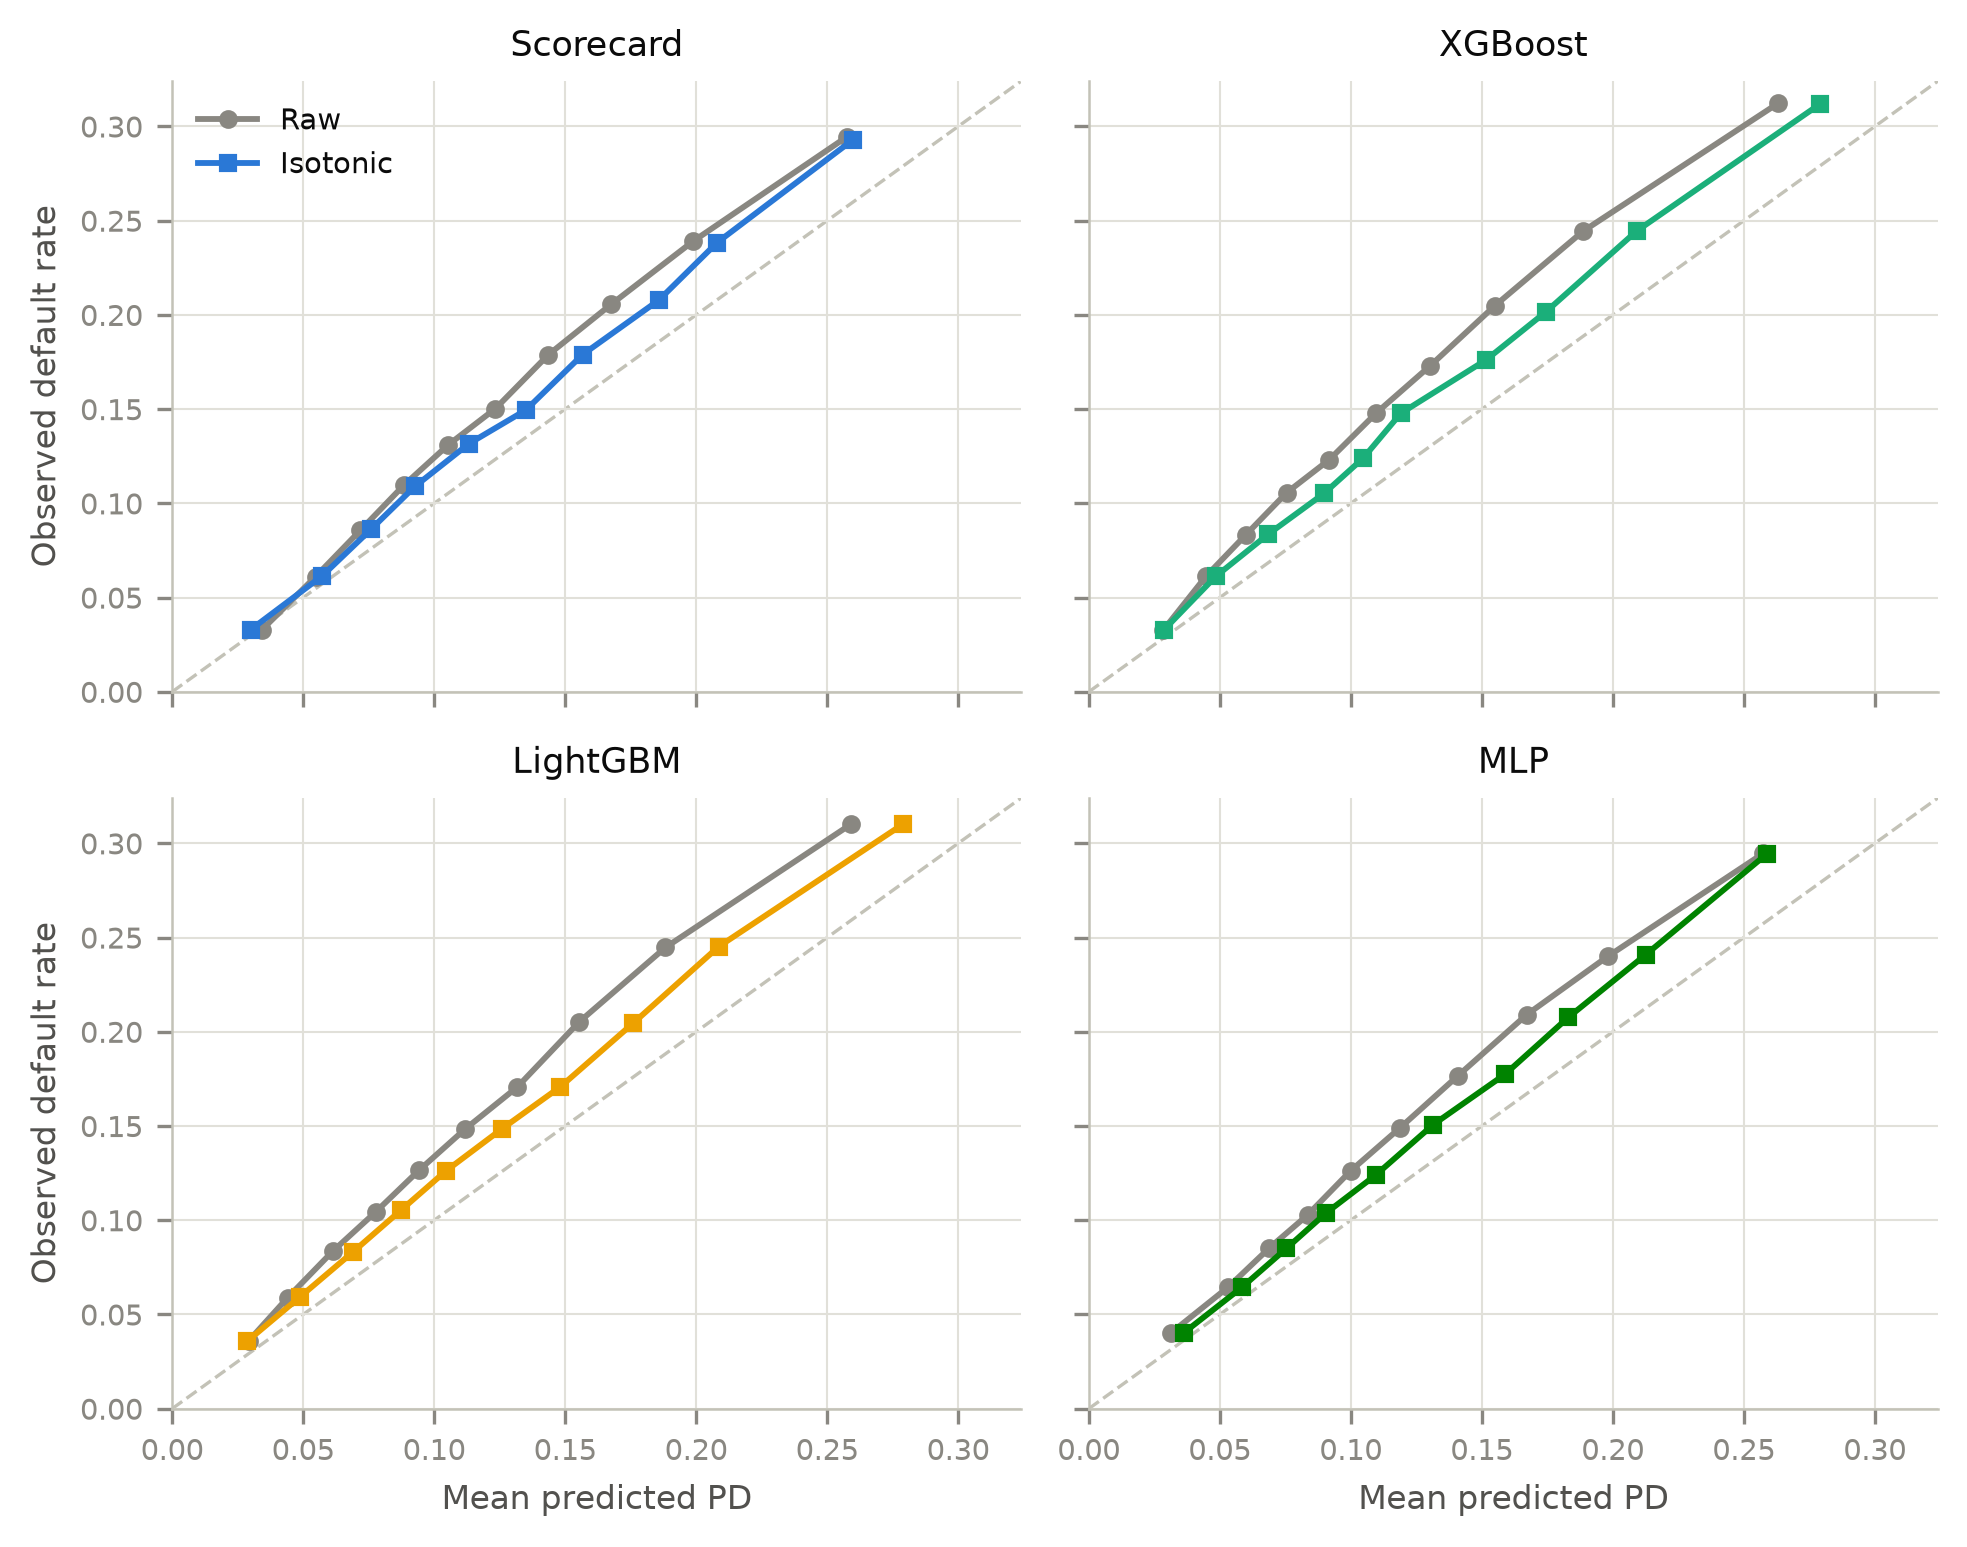

In [4]:
display(Image(str(FIGURES / "fig_reliability.png"), width=760))

## 4. The decision layer: profit per 1,000 applicants

Accept every applicant with predicted PD ≤ cutoff; realized profit uses actual outcomes (repaid loan earns its total interest; charged-off loan loses LGD × principal, LGD = 0.65). Dots mark each model's best operating point.

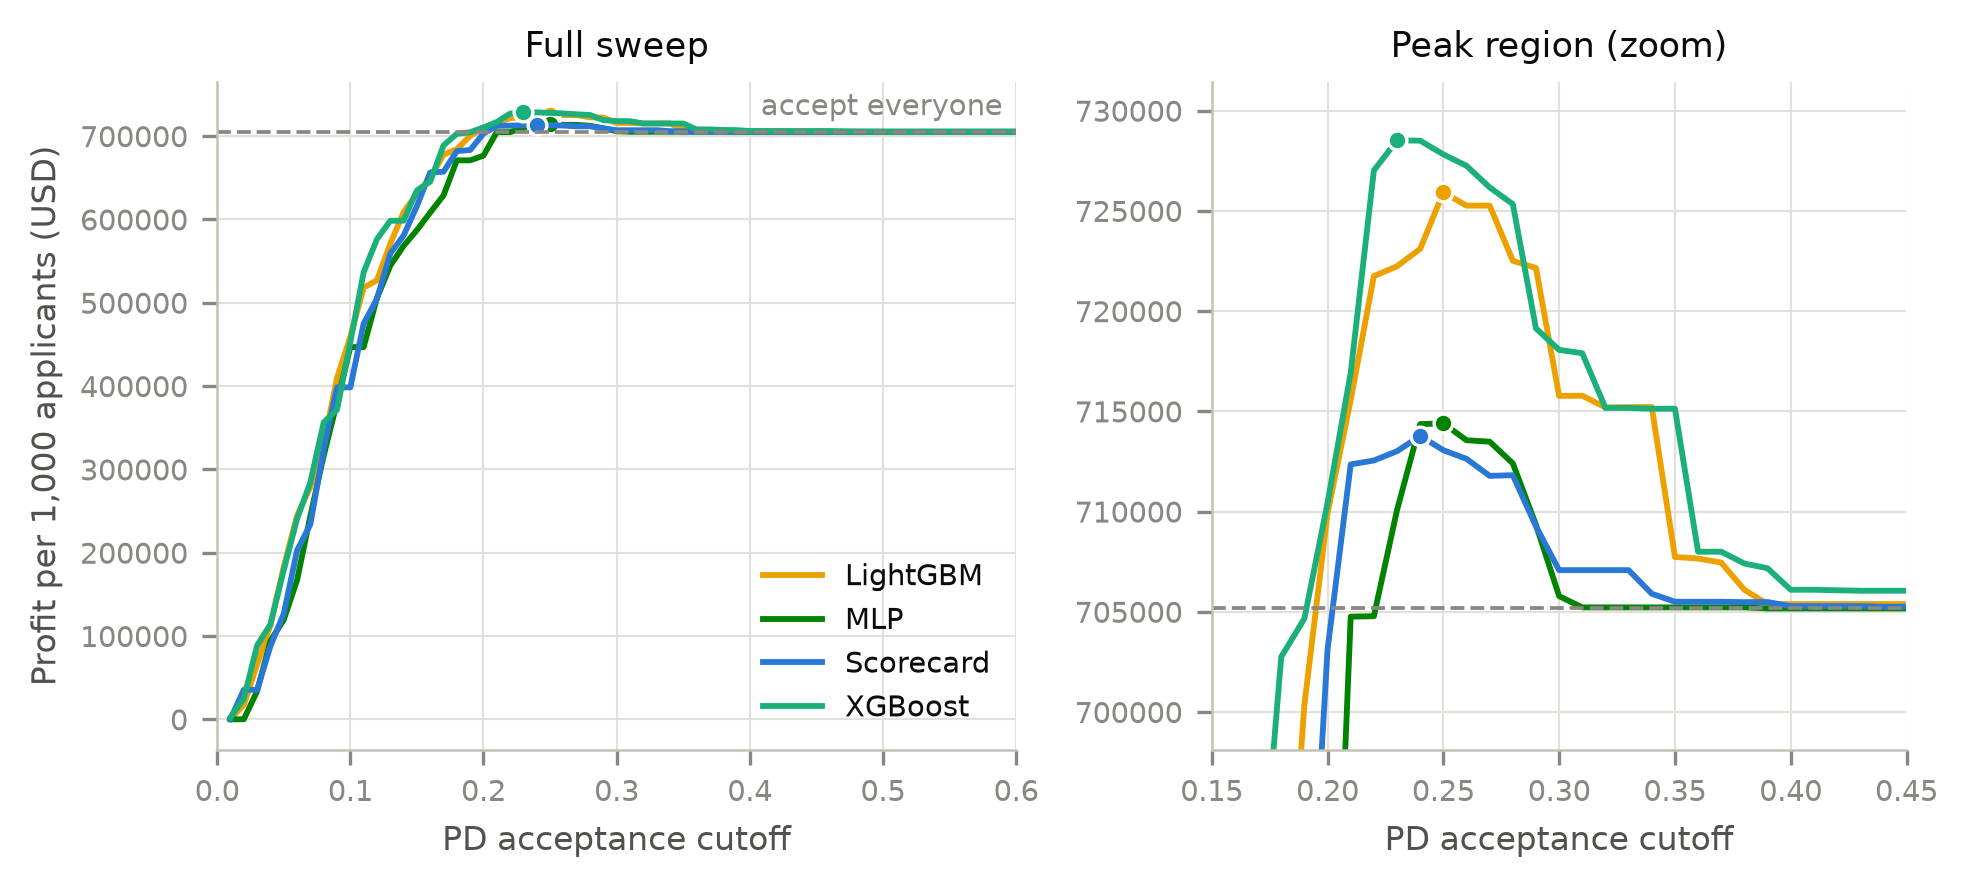

,model,cutoff,accept_rate,profit_per_1000
0,scorecard,0.24,0.9328,713772.4633
1,xgboost,0.23,0.9066,728516.6205
2,lightgbm,0.25,0.9365,725927.2186
3,mlp,0.25,0.9398,714401.1432
4,accept_all,1.00,1.0000,705170.8092


In [5]:
display(Image(str(FIGURES / "fig_profit.png"), width=760))
pd.read_csv(RESULTS / "operating_points_lc.csv").round(4)

## 5. The scorecard itself

Score distributions for repaid vs. charged-off loans (the classic KS picture), and what the two model families consider important: XGBoost gain importance vs. scorecard information value.

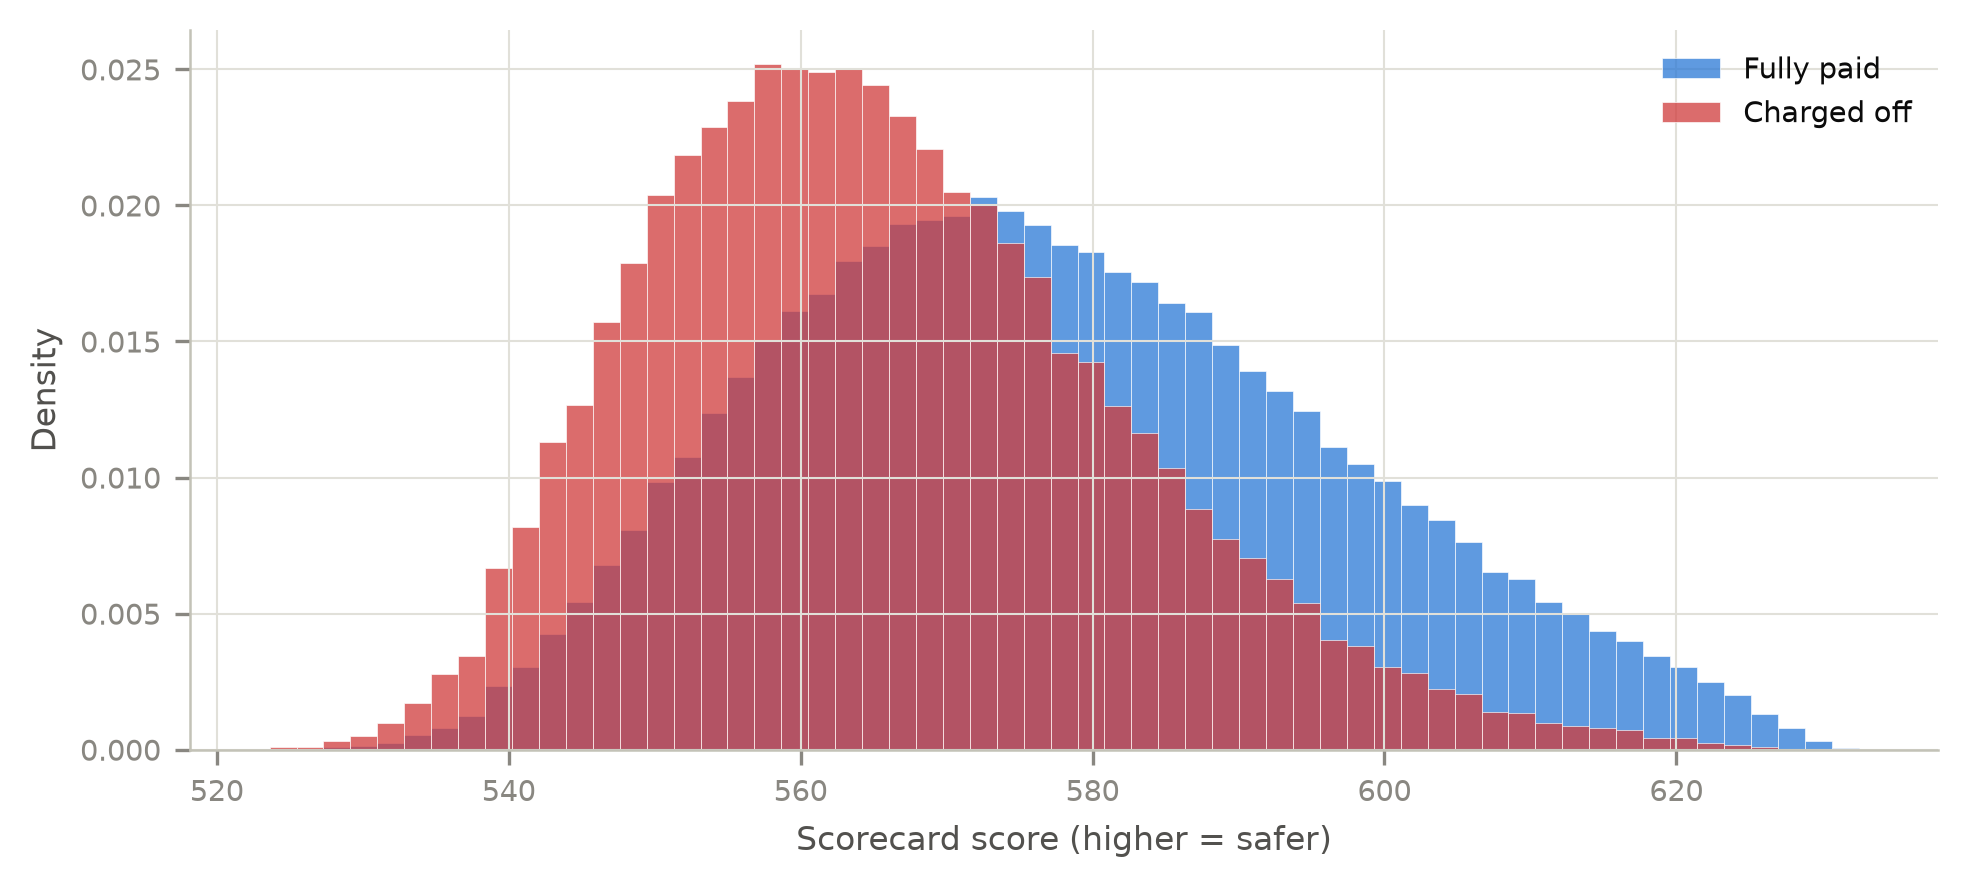

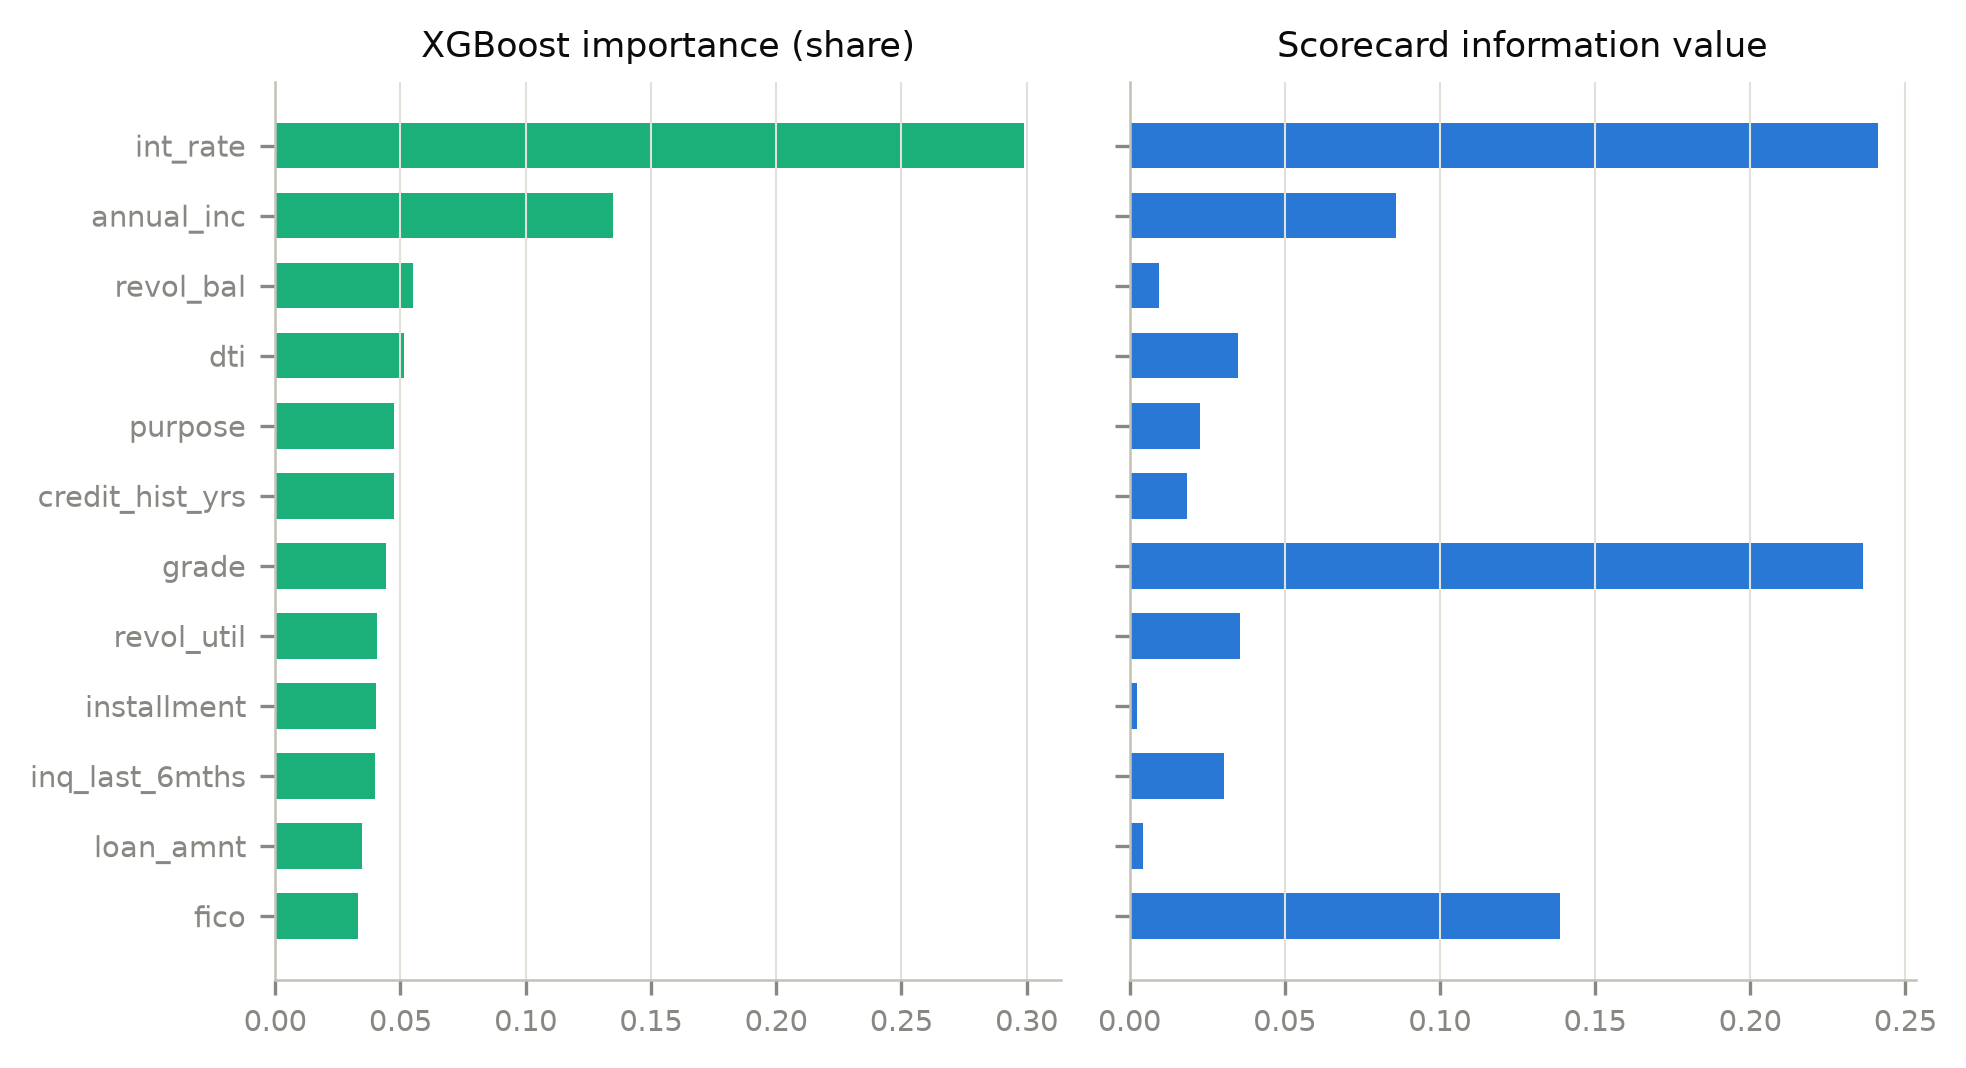

,feature,xgb_importance,iv
0,annual_inc,0.1349,0.0858
1,application_type,0.0000,0.0000
2,credit_hist_yrs,0.0473,0.0186
3,delinq_2yrs,0.0039,0.0004
4,dti,0.0515,0.0349
5,emp_length_yrs,0.0216,0.0119
6,fico,0.0333,0.1387
7,grade,0.0443,0.2364
8,home_ownership,0.0096,0.0282
9,inq_last_6mths,0.0400,0.0306


In [6]:
display(Image(str(FIGURES / "fig_score_dist.png"), width=760))
display(Image(str(FIGURES / "fig_importance.png"), width=760))
pd.read_csv(RESULTS / "importance_lc.csv").round(4)

## 6. Robustness: UCI Taiwan credit-card default

In [7]:
import json

tw = pd.read_csv(RESULTS / "leaderboard_taiwan.csv")
display(tw.sort_values(["calibration", "auc_mean"], ascending=[True, False]).round(4))
print(json.dumps(json.loads((RESULTS / "summary_taiwan.json").read_text()), indent=2))

,model,calibration,auc_mean,auc_std,ks_mean,brier_mean,brier_std,ece_mean,ece_std
9,xgboost,isotonic,0.7873,0.0010,0.4498,0.1330,0.0002,0.0162,0.0029
0,lightgbm,isotonic,0.7850,0.0011,0.4455,0.1334,0.0002,0.0160,0.0014
6,scorecard,isotonic,0.7692,NaN,0.4186,0.1363,NaN,0.0127,NaN
3,mlp,isotonic,0.7652,0.0044,0.4166,0.1362,0.0004,0.0171,0.0022
10,xgboost,platt,0.7880,0.0009,0.4527,0.1324,0.0002,0.0137,0.0011
1,lightgbm,platt,0.7859,0.0007,0.4504,0.1330,0.0001,0.0145,0.0018
7,scorecard,platt,0.7717,NaN,0.4213,0.1361,NaN,0.0171,NaN
4,mlp,platt,0.7662,0.0041,0.4198,0.1362,0.0005,0.0200,0.0028
11,xgboost,raw,0.7880,0.0009,0.4527,0.1324,0.0002,0.0126,0.0017
2,lightgbm,raw,0.7859,0.0007,0.4504,0.1336,0.0004,0.0256,0.0058


{
  "auc_diff_xgb_vs_scorecard": 0.014971849217659372,
  "delong_p": 2.7806724759938412e-06,
  "n_test": 6000,
  "bad_rate_test": 0.22116666666666668
}


## 7. Study summary

In [8]:
print(json.dumps(json.loads((RESULTS / "summary_lc.json").read_text()), indent=2))

{
  "n_train": 175426,
  "n_val": 162570,
  "n_test": 283026,
  "bad_rate_train": 0.12630396862494728,
  "bad_rate_val": 0.13726394783785445,
  "bad_rate_test": 0.14886264866125373,
  "scorecard_features": [
    "sub_grade",
    "int_rate",
    "grade",
    "fico",
    "annual_inc",
    "revol_util",
    "dti",
    "inq_last_6mths",
    "mort_acc",
    "home_ownership",
    "purpose"
  ],
  "spearman_importance_vs_iv": 0.5612648221343874,
  "accept_all_profit_per_1000": 705170.8092189409,
  "runtime_s": 992.1
}
